In [65]:
import pandas
import os

In [85]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [86]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_vehicules = []

for year in years:
    df_vehicules_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"vehicules-{year}.csv"), encoding="utf-8", sep = ";")
    df_vehicules.append(df_vehicules_year)

df_vehicules = pandas.concat(df_vehicules)
df_vehicules

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,201900000001,138 306 524,B01,2,7,0,2,5,23,1,NaN
1,201900000001,138 306 525,A01,2,17,1,0,3,11,1,NaN
2,201900000002,138 306 523,A01,1,7,4,0,1,0,1,NaN
3,201900000003,138 306 520,A01,1,7,0,2,1,2,1,NaN
4,201900000003,138 306 521,B01,1,7,1,0,4,2,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
92673,202400054401,155 686 119,Y01,1,60,1,2,7,0,5,NaN
92674,202400054401,155 686 120,A01,1,33,1,2,1,1,1,NaN
92675,202400054402,155 686 118,A01,1,10,0,2,1,2,1,NaN
92676,202400054402,155 686 121,B01,1,7,0,2,4,2,1,NaN


In [87]:
df_vehicules["id_vehicule"] = (
    df_vehicules["id_vehicule"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # keep only digits
    .astype("int64")
)

In [88]:
df_vehicules.replace(-1, pandas.NA, inplace=True)

for col in df_vehicules.columns:
    prop = df_vehicules[col].isna().sum() / len(df_vehicules)
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For id_vehicule proportion missing: 0.00%
For num_veh proportion missing: 0.00%
For senc proportion missing: 0.26%
For catv proportion missing: 0.00%
For obs proportion missing: 0.04%
For obsm proportion missing: 0.05%
For choc proportion missing: 0.05%
For manv proportion missing: 0.04%
For motor proportion missing: 0.22%
For occutc proportion missing: 99.13%


In [89]:
# First we are dropping features that we are not going to use: num_veh as we will use id_vehicule instead
df_vehicules.drop(columns = ['num_veh', 'senc', 'occutc'], inplace = True)

In [90]:
# Removing rows with missing values
df_vehicules = df_vehicules.dropna()

In [91]:
# And converting to int
cols_small_int = ['catv', 'obs', 'obsm', 'choc', 'manv', 'motor']
df_vehicules[cols_small_int] = df_vehicules[cols_small_int].astype("int64")

In [92]:
categorical_features = cols_small_int[:]
numerical_features = []
features = categorical_features + numerical_features

In [93]:
# We need to load usagers, because it conatains our target column
df_usagers = pandas.read_csv("df_usagers_clean.csv")

df_vehicules_with_target = df_vehicules.merge(
    df_usagers[['Num_Acc', 'id_vehicule', 'grav_bin']],
    on=['Num_Acc', 'id_vehicule'],
    how='left'
)

target = "grav_bin"

In [96]:
df_vehicules_with_target = df_vehicules_with_target.dropna()

In [97]:
df_vehicules_analyse = df_vehicules_with_target.copy() 

mapping = {
    0: "Indéterminable",
    1: "Bicyclette",
    2: "Cyclomoteur <50cm3",
    3: "Voiturette (Quadricycle à moteur carrossé)",
    4: "Référence inutilisée depuis 2006 (scooter immatriculé)",
    5: "Référence inutilisée depuis 2006 (motocyclette)",
    6: "Référence inutilisée depuis 2006 (side-car)",
    7: "VL seul",
    8: "Référence inutilisée depuis 2006 (VL + caravane)",
    9: "Référence inutilisée depuis 2006 (VL + remorque)",
    10: "VU seul 1,5T <= PTAC <= 3,5T avec ou sans remorque",
    11: "Référence inutilisée depuis 2006 (VU (10) + caravane)",
    12: "Référence inutilisée depuis 2006 (VU (10) + remorque)",
    13: "PL seul 3,5T < PTAC <= 7,5T",
    14: "PL seul > 7,5T",
    15: "PL > 3,5T + remorque",
    16: "Tracteur routier seul",
    17: "Tracteur routier + semi-remorque",
    18: "Référence inutilisée depuis 2006 (transport en commun)",
    19: "Référence inutilisée depuis 2006 (tramway)",
    20: "Engin spécial",
    21: "Tracteur agricole",
    30: "Scooter < 50 cm3",
    31: "Motocyclette > 50 cm3 et <= 125 cm3",
    32: "Scooter > 50 cm3 et <= 125 cm3",
    33: "Motocyclette > 125 cm3",
    34: "Scooter > 125 cm3",
    35: "Quad léger <= 50 cm3 (Quadricycle à moteur non carrossé)",
    36: "Quad lourd > 50 cm3 (Quadricycle à moteur non carrossé)",
    37: "Autobus",
    38: "Autocar",
    39: "Train",
    40: "Tramway",
    41: "3RM <= 50 cm3",
    42: "3RM > 50 cm3 <= 125 cm3",
    43: "3RM > 125 cm3",
    50: "EDP à moteur",
    60: "EDP sans moteur",
    80: "VAE",
    99: "Autre véhicule"
}

df_vehicules_analyse["catv"] = df_vehicules_analyse["catv"].replace(mapping)

mapping = {
    0: "Sans objet",
    1: "Véhicule en stationnement",
    2: "Arbre",
    3: "Glissière métallique",
    4: "Glissière béton",
    5: "Autre glissière",
    6: "Bâtiment, mur, pile de pont",
    7: "Support de signalisation verticale ou poste d’appel d’urgence",
    8: "Poteau",
    9: "Mobilier urbain",
    10: "Parapet",
    11: "Ilot, refuge, borne haute",
    12: "Bordure de trottoir",
    13: "Fossé, talus, paroi rocheuse",
    14: "Autre obstacle fixe sur chaussée",
    15: "Autre obstacle fixe sur trottoir ou accotement",
    16: "Sortie de chaussée sans obstacle",
    17: "Buse – tête d’aqueduc"
}

df_vehicules_analyse["obs"]= df_vehicules_analyse["obs"].replace(mapping)

mapping = {
    0: "Aucun",
    1: "Piéton",
    2: "Véhicule",
    4: "Véhicule sur rail",
    5: "Animal domestique",
    6: "Animal sauvage",
    9: "Autre"
}

df_vehicules_analyse["obsm"]= df_vehicules_analyse["obsm"].replace(mapping)

mapping = {
    0: "Aucun",
    1: "Avant",
    2: "Avant droit",
    3: "Avant gauche",
    4: "Arrière",
    5: "Arrière droit",
    6: "Arrière gauche",
    7: "Côté droit",
    8: "Côté gauche",
    9: "Chocs multiples (tonneaux)"
}

df_vehicules_analyse["choc"]= df_vehicules_analyse["choc"].replace(mapping)

mapping = {
    0: "Inconnue",
    1: "Sans changement de direction",
    2: "Même sens, même file",
    3: "Entre 2 files",
    4: "En marche arrière",
    5: "A contresens",
    6: "En franchissant le terre-plein central",
    7: "Dans le couloir bus, dans le même sens",
    8: "Dans le couloir bus, dans le sens inverse",
    9: "En s’insérant",
    10: "En faisant demi-tour sur la chaussée",
    11: "A gauche (changeant de file)",
    12: "A droite (changeant de file)",
    13: "A gauche (déporté)",
    14: "A droite (déporté)",
    15: "A gauche (tournant)",
    16: "A droite (tournant)",
    17: "A gauche (dépassant)",
    18: "A droite (dépassant)",
    19: "Traversant la chaussée",
    20: "Manœuvre de stationnement",
    21: "Manœuvre d’évitement",
    22: "Ouverture de porte",
    23: "Arrêté (hors stationnement)",
    24: "En stationnement (avec occupants)",
    25: "Circulant sur trottoir",
    26: "Autres manœuvres"
}

df_vehicules_analyse["manv"]= df_vehicules_analyse["manv"].replace(mapping)

mapping = {
    0: "Inconnue",
    1: "Hydrocarbures",
    2: "Hybride électrique",
    3: "Electrique",
    4: "Hydrogène",
    5: "Humaine",
    6: "Autre"
}

df_vehicules_analyse["motor"]= df_vehicules_analyse["motor"].replace(mapping)

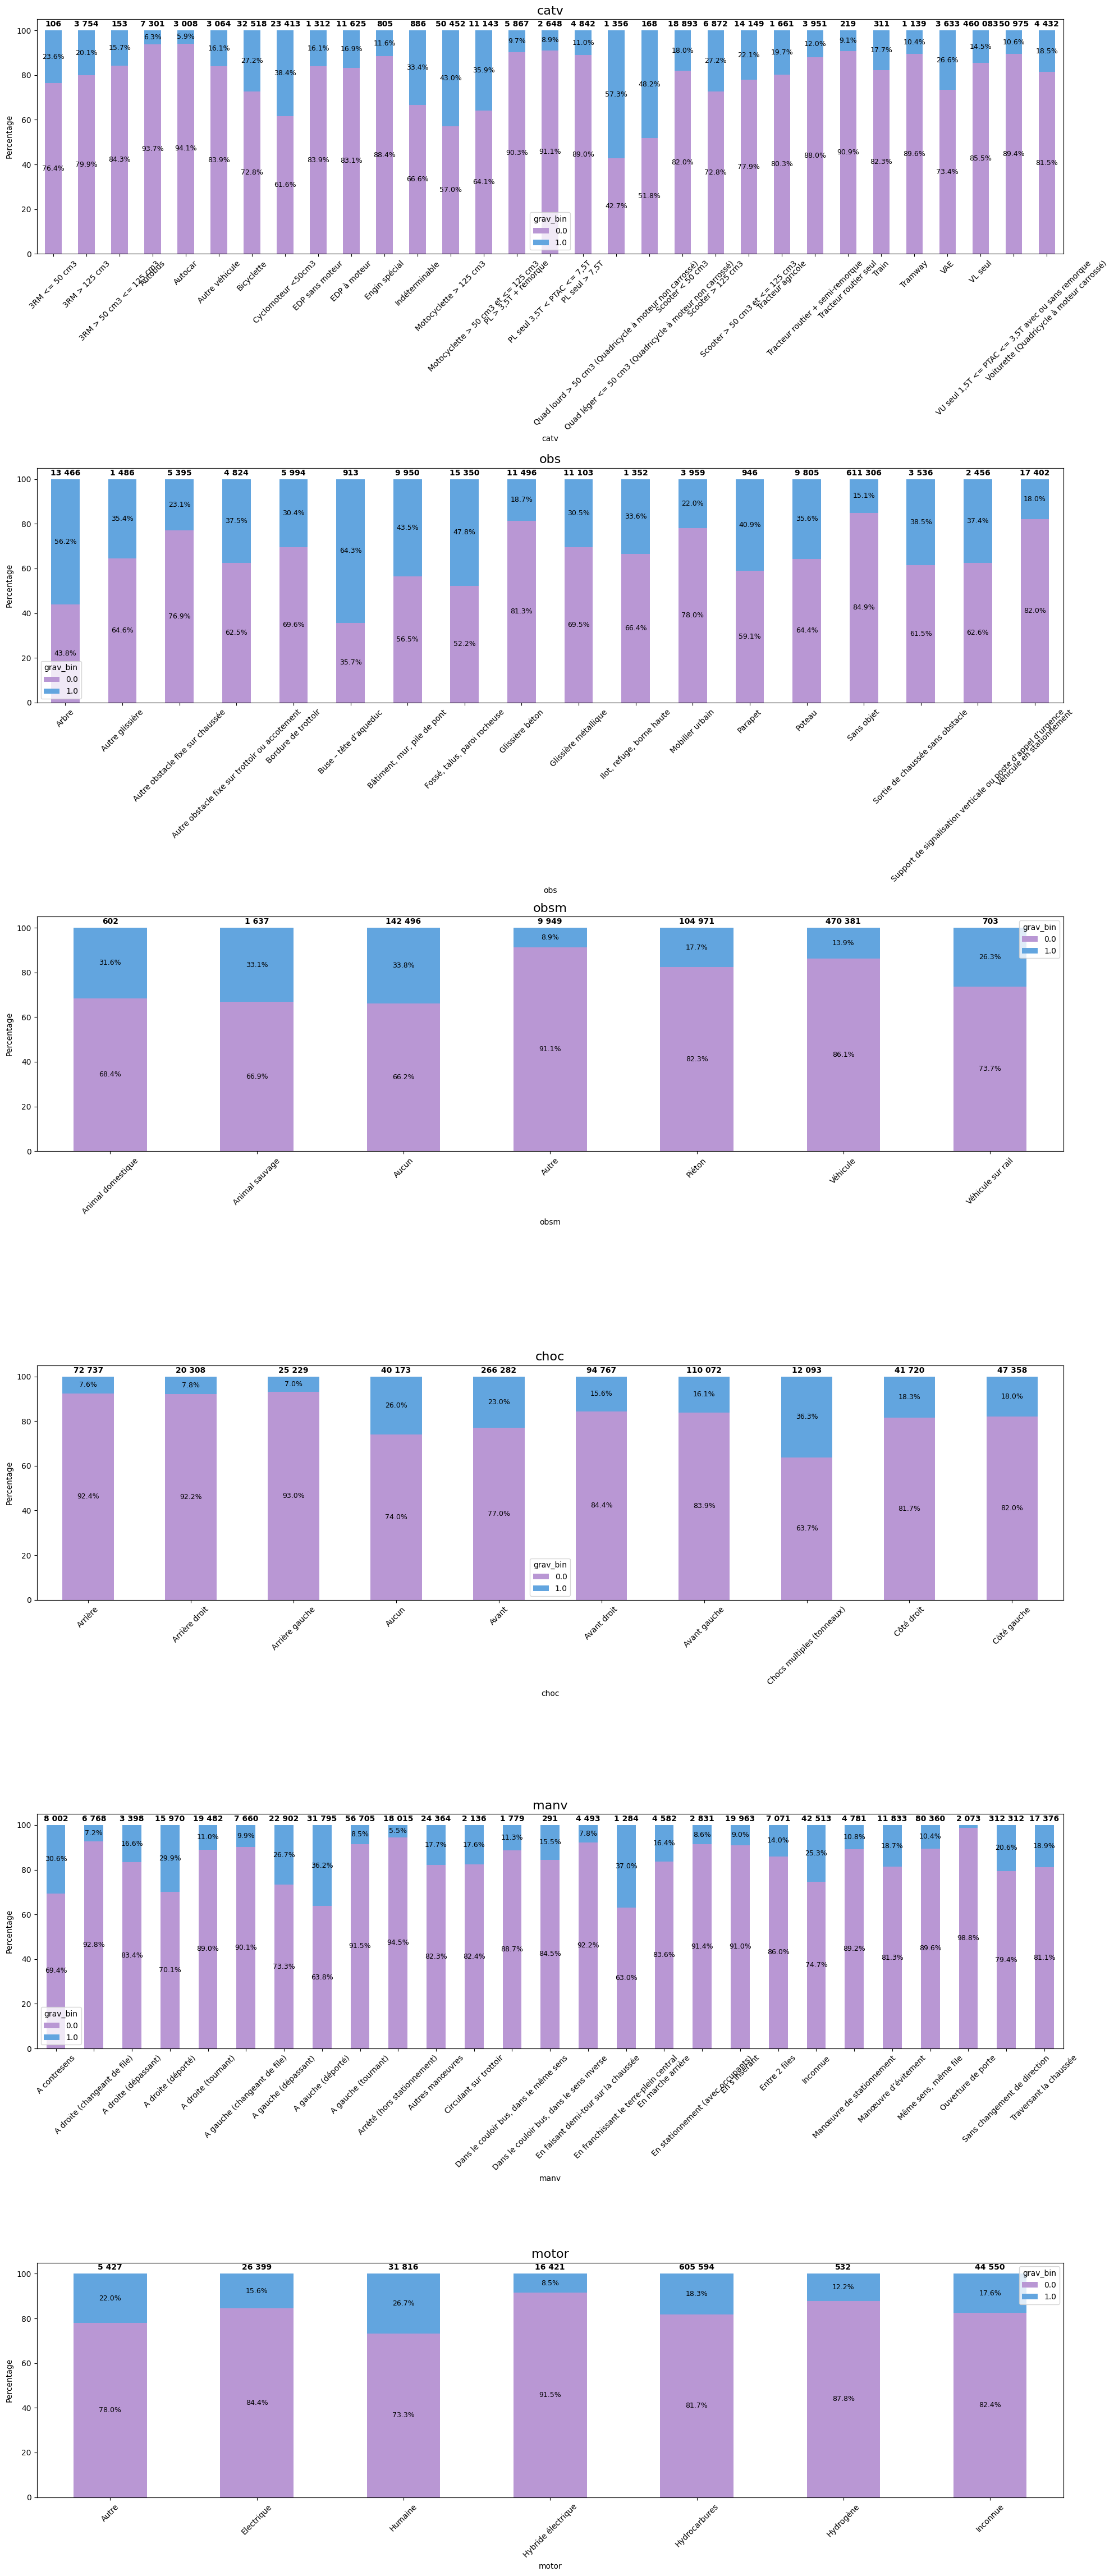

In [98]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(len(categorical_features), 1, figsize=(20, 6*len(categorical_features) + 10))

for i, feature in enumerate(categorical_features):
    ct = pandas.crosstab(
        df_vehicules_analyse[feature],
        df_vehicules_analyse[target],
        normalize="index"
    ) * 100

    counts = df_vehicules_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [99]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [100]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_vehicules_with_target[categorical_features + numerical_features]
y = df_vehicules_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

In [102]:
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))


 Logistic Regression
Accuracy: 0.8248624681829378

 Decision Tree
Accuracy: 0.8247119358458549

 Gradient Boosting
Accuracy: 0.825970933574185


AUC of Logistic Regression: 0.765
AUC of Decision Tree: 0.754
AUC of Gradient Boosting: 0.769


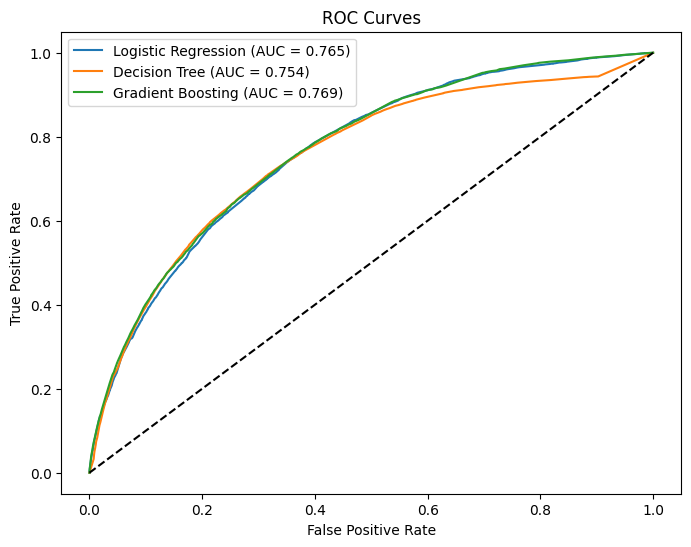

In [103]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
lst_auc = []

for name, pipe in pipelines.items(): 
    if hasattr(pipe["model"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    elif hasattr(pipe["model"], "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        # fallback: just use predictions (not ideal for ROC, but works)
        y_score = model.predict(X_test)
        print(f"Warning: {name} does not have predict_proba or decision_function, using predict()")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [104]:
# Finally we are going to save the dataset cleaned
df_vehicules.to_csv("df_vehicules_clean.csv", index=False)

We have many categories, what happens when we will take into account only the vehicule group ?

In [105]:
# Grouping too specific categories of vehicule into more broad types:
vehicle_group_map = {
    # other / unknown
    0: 0,
    99: 0,

    # bicycles
    1: 1,

    # motorcycles / 2-3 wheels
    2: 2,
    4: 2,
    5: 2,
    6: 2,
    30: 2,
    31: 2,
    32: 2,
    33: 2,
    34: 2,
    35: 2,
    36: 2,
    41: 2,
    42: 2,
    43: 2,

    # cars
    3: 3,
    7: 3,
    8: 3,
    9: 3,

    # light utility vehicles
    10: 4,
    11: 4,
    12: 4,

    # trucks / heavy vehicles
    13: 5,
    14: 5,
    15: 5,
    16: 5,
    17: 5,

    # public transport
    18: 6,
    19: 6,
    37: 6,
    38: 6,

    # agricultural / special machinery
    20: 7,
    21: 7,

    # rail vehicles
    39: 6,
    40: 6,

    # micromobility
    50: 8,
    60: 8,
    80: 8
}

df_vehicules_with_target["catv"] = df_vehicules_with_target["catv"].map(vehicle_group_map)

In [106]:
df_vehicules_with_target = df_vehicules_with_target.dropna()

In [107]:
df_vehicules_with_target["catv"].unique()

array([3, 5, 2, 6, 8, 4, 1, 0, 7])


 Logistic Regression
Accuracy: 0.8248556258039795

 Decision Tree
Accuracy: 0.8244313983085639

 Gradient Boosting
Accuracy: 0.8253688042258532

AUC of Logistic Regression: 0.759
AUC of Decision Tree: 0.759
AUC of Gradient Boosting: 0.770


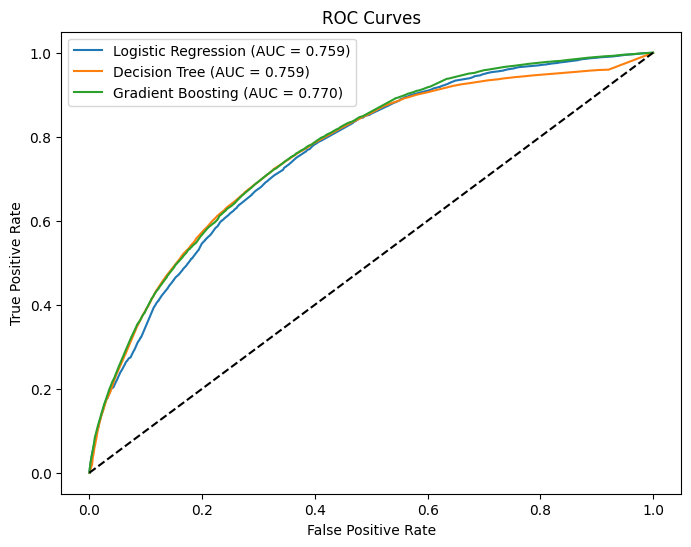

In [108]:
X = df_vehicules_with_target[categorical_features + numerical_features]
y = df_vehicules_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))

print()

plt.figure(figsize=(8,6))
lst_auc = []

for name, pipe in pipelines.items(): 
    if hasattr(pipe["model"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    elif hasattr(pipe["model"], "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        # fallback: just use predictions (not ideal for ROC, but works)
        y_score = model.predict(X_test)
        print(f"Warning: {name} does not have predict_proba or decision_function, using predict()")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [109]:
obs_group_map = {
    0: 0,

    1: 1,

    # rigid obstacles
    2: 2,
    6: 2,

    # barriers
    3: 3,
    4: 3,
    5: 3,

    # roadside objects
    7: 4,
    8: 4,
    9: 4,

    # road infrastructure
    10: 5,
    11: 5,
    12: 5,

    # terrain
    13: 6,
    17: 6,

    # other obstacles
    14: 7,
    15: 7,

    16: 8
}

df_vehicules_with_target["obs"] = df_vehicules_with_target["obs"].map(obs_group_map)

In [110]:
df_vehicules_with_target["catv"].unique()

array([3, 5, 2, 6, 8, 4, 1, 0, 7])


 Logistic Regression
Accuracy: 0.8239729589183568

 Decision Tree
Accuracy: 0.8243013931083559

 Gradient Boosting
Accuracy: 0.8249787886252292

AUC of Logistic Regression: 0.757
AUC of Decision Tree: 0.762
AUC of Gradient Boosting: 0.771


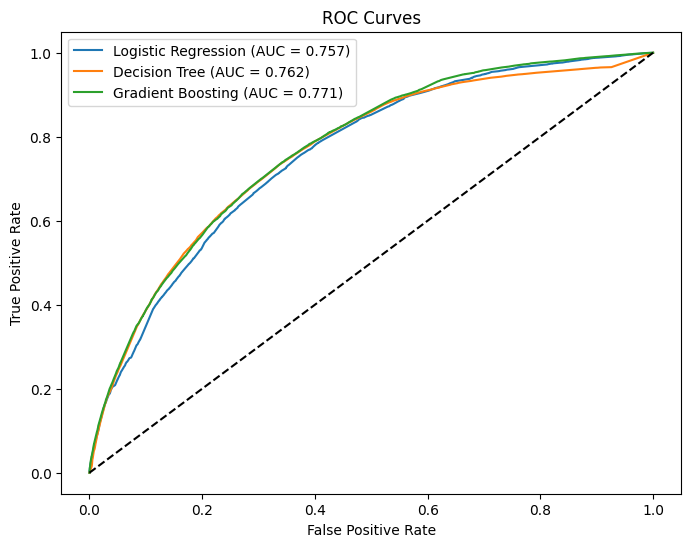

In [111]:
X = df_vehicules_with_target[categorical_features + numerical_features]
y = df_vehicules_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))

print()

plt.figure(figsize=(8,6))
lst_auc = []

for name, pipe in pipelines.items(): 
    if hasattr(pipe["model"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    elif hasattr(pipe["model"], "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        # fallback: just use predictions (not ideal for ROC, but works)
        y_score = model.predict(X_test)
        print(f"Warning: {name} does not have predict_proba or decision_function, using predict()")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [112]:
maneuver_group_map = {
    0: 0,

    # straight movement
    1: 1,
    2: 1,

    # lane change / lateral movement
    3: 2,
    11: 2,
    12: 2,
    13: 2,
    14: 2,

    # turning
    15: 3,
    16: 3,

    # overtaking
    17: 4,
    18: 4,

    # crossing / entering road
    9: 5,
    10: 5,
    19: 5,

    # abnormal directions
    4: 6,
    5: 6,
    6: 6,

    # stopped / parking
    20: 7,
    23: 7,
    24: 7,

    # avoidance
    21: 8,

    # door
    22: 9,

    # sidewalk
    25: 10,

    # bus lane
    7: 11,
    8: 11,

    # other
    26: 12
}

df_vehicules_with_target["manv"] = df_vehicules_with_target["manv"].map(maneuver_group_map)

In [113]:
df_vehicules_with_target = df_vehicules_with_target.dropna()


 Logistic Regression
Accuracy: 0.8230150258641925

 Decision Tree
Accuracy: 0.8240482250868982

 Gradient Boosting
Accuracy: 0.8241166488764814

AUC of Logistic Regression: 0.748
AUC of Decision Tree: 0.759
AUC of Gradient Boosting: 0.762


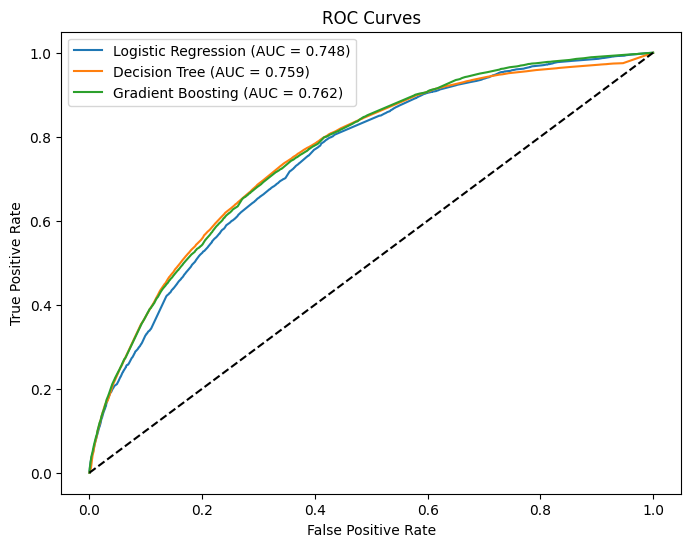

In [114]:
X = df_vehicules_with_target[categorical_features + numerical_features]
y = df_vehicules_with_target[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))

print()

plt.figure(figsize=(8,6))
lst_auc = []

for name, pipe in pipelines.items(): 
    if hasattr(pipe["model"], "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:,1]
    elif hasattr(pipe["model"], "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        # fallback: just use predictions (not ideal for ROC, but works)
        y_score = model.predict(X_test)
        print(f"Warning: {name} does not have predict_proba or decision_function, using predict()")

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = auc(fpr, tpr)
    lst_auc.append((name, auc_score))

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")
    print(f"AUC of {name}: {auc_score:.3f}")

plt.plot([0,1],[0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()